# Diabetes Classification Project
**Dataset:** Pima Indians Diabetes Database  
**Target:** Predict whether a patient has diabetes (`Outcome`: 0 = Healthy, 1 = Diabetic)

---
### Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases.  
All patients are **females at least 21 years old** of Pima Indian heritage.

| Column | Description |
|:---|:---|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration (2h oral glucose tolerance test) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-Hour serum insulin (mu U/ml) |
| BMI | Body mass index (kg/m²) |
| DiabetesPedigreeFunction | Diabetes pedigree function |
| Age | Age (years) |
| Outcome | Class variable (0 or 1) |

## 1. Imports

In [38]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

RSEED = 42
warnings.filterwarnings("ignore")

## 2. Helper Functions

All reusable functions are defined here at the top so they are available throughout the notebook.

In [39]:
def remove_outliers(df, columns):
    """
    Removes rows with outliers using IQR method.
    NaN values are preserved for later imputation in the pipeline.
    Bounds are computed only from the training data passed in — no leakage.
    """
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound) | (df[col].isna())]
    return df

In [40]:
def plot_target_correlation(data, target_col, title="Feature Correlation with Target"):
    """Plots a sorted heatmap showing the correlation of all features with the target."""
    correlations = data.corr(numeric_only=True)[[target_col]]
    correlations = correlations.sort_values(by=target_col, ascending=False)
    correlations = correlations.drop(target_col)

    plt.figure(figsize=(5, 8))
    sns.heatmap(correlations, annot=True, cmap='viridis',
                vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title(f"{title}: {target_col}")
    plt.show()

In [41]:
def hist_plot(df, features, title=""):
    """
    Plots histograms with KDE for each feature.
    Shows mean, median and skewness score to help decide which scaler to use.
    """
    fig, axes = plt.subplots(4, 2, figsize=(15, 18))
    axes = axes.flatten()

    for i, col in enumerate(features):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
        s = df[col].skew()
        axes[i].set_title(f'{col} (Skew: {s:.2f})', fontsize=14)
        axes[i].set_xlabel('')
        mean_val   = df[col].mean()
        median_val = df[col].median()
        axes[i].axvline(mean_val,   color='red',  linestyle='--', label=f'Mean: {mean_val:.1f}')
        axes[i].axvline(median_val, color='gold', linestyle='-',  label=f'Median: {median_val:.1f}')
        axes[i].legend()

    if title:
        fig.suptitle(title, fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

In [42]:
def plot_model_comparison(results_df, title_suffix=""):
    """
    Plots Recall and Accuracy comparison bar charts.

    Parameters:
        results_df   : DataFrame with columns ['Model', 'Set', 'Recall', 'Accuracy']
        title_suffix : String appended to chart titles for context
    """
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    sns.barplot(data=results_df, x='Model', y='Recall', hue='Set', ax=ax[0])
    ax[0].set_title(f'Recall: {title_suffix}')
    ax[0].set_ylim(0, 1)

    sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Set', ax=ax[1])
    ax[1].set_title(f'Accuracy: {title_suffix}')
    ax[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

## 3. Load Data

In [43]:
df = pd.read_csv('data/diabetes.csv')
df.sample(10)

,id,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,Age,outcome
32,33,3,88,58,11,54,24.8,0.267,22,0
124,125,0,113,76,0,0,33.3,0.278,23,1
713,714,0,134,58,20,291,26.4,0.352,21,0
626,627,0,125,68,0,0,24.7,0.206,21,0
745,746,12,100,84,33,105,30.0,0.488,46,0
420,421,1,119,88,41,170,45.3,0.507,26,0
675,676,6,195,70,0,0,30.9,0.328,31,1
452,453,0,91,68,32,210,39.9,0.381,25,0
307,308,0,137,68,14,148,24.8,0.143,21,0
747,748,1,81,74,41,57,46.3,1.096,32,0


## 4. Exploration & Cleaning

- Several columns contain **physiologically impossible zeros** (e.g. glucose = 0, BMI = 0).
- These are not valid values — they represent **missing data**.
- We replace them with `NaN` so the pipeline can impute them properly.

In [44]:
df.set_index('id', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 1 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 60.0 KB


In [45]:
print(df.isnull().sum())
print(f'Rows: {df.shape[0]}, Features: {df.shape[1]}')
df.nunique()

pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
Age                         0
outcome                     0
dtype: int64
Rows: 768, Features: 9


pregnancies                  17
glucose                     136
bloodpressure                47
skinthickness                51
insulin                     186
bmi                         248
diabetespedigreefunction    517
Age                          52
outcome                       2
dtype: int64

In [46]:
df.columns = df.columns.str.lower()

# Columns where 0 is physiologically impossible → treat as NaN
zero_check_columns = ['glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi']
other_columns      = ['pregnancies', 'diabetespedigreefunction', 'age']

zero_counts = (df[zero_check_columns] == 0).sum()
print("Zero counts per column:")
print(zero_counts)

Zero counts per column:
glucose            5
bloodpressure     35
skinthickness    227
insulin          374
bmi               11
dtype: int64


In [47]:
# Replace invalid zeros with NaN — will be imputed later in the pipeline
df[zero_check_columns] = df[zero_check_columns].replace(0, np.nan)
df[zero_check_columns].head()

,glucose,bloodpressure,skinthickness,insulin,bmi
id,,,,,
1,148.0,72.0,35.0,NaN,33.6
2,85.0,66.0,29.0,NaN,26.6
3,183.0,64.0,NaN,NaN,23.3
4,89.0,66.0,23.0,94.0,28.1
5,137.0,40.0,35.0,168.0,43.1


## 5. Train-Test Split

- `stratify=y` ensures the class ratio is preserved in both splits.
- All EDA and preprocessing decisions are made on **training data only** to avoid data leakage.

In [48]:
X = df.drop('outcome', axis=1)
y = df['outcome']

print(f'Dataset: {X.shape[0]} observations, {X.shape[1]} features')
print(f'Class balance:\n{y.value_counts(normalize=True).round(2)}')

Dataset: 768 observations, 8 features
Class balance:
outcome
0    0.65
1    0.35
Name: proportion, dtype: float64


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RSEED, stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (614, 8)
X_test:  (154, 8)
y_train: (614,)
y_test:  (154,)


In [50]:
# Working dataframe for EDA — training data only
df_train = pd.concat([X_train, y_train], axis=1)
df_train.describe()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
count,614.000000,610.000000,591.000000,439.000000,324.000000,605.000000,614.000000,614.000000,614.000000
mean,3.819218,121.701639,72.145516,29.059226,149.077160,32.448926,0.477428,33.366450,0.348534
std,3.314148,30.099771,12.512061,10.519221,107.234748,6.874773,0.330300,11.833438,0.476895
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.084000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,21.000000,76.000000,27.600000,0.245000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.382500,29.000000,0.000000
75%,6.000000,140.750000,80.000000,36.000000,183.500000,36.600000,0.639250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000,1.000000


## 6. Outlier Removal

- Outliers are removed using the **IQR method**.
- Applied **only on training data** — bounds are never computed from test data.
- `NaN` values are preserved so the imputer in the pipeline can handle them.

In [51]:
outlier_features = ['glucose', 'bloodpressure', 'skinthickness',
                    'insulin', 'bmi', 'diabetespedigreefunction']

# Outlier bounds computed only on training data — no leakage into test set
df_cleaned      = remove_outliers(df_train, outlier_features)
X_train_cleaned = df_cleaned.drop('outcome', axis=1)
y_train_cleaned = df_cleaned['outcome']

print(f"Original rows:              {len(df_train)}")
print(f"Rows after outlier removal: {len(df_cleaned)}")

Original rows:              614
Rows after outlier removal: 558


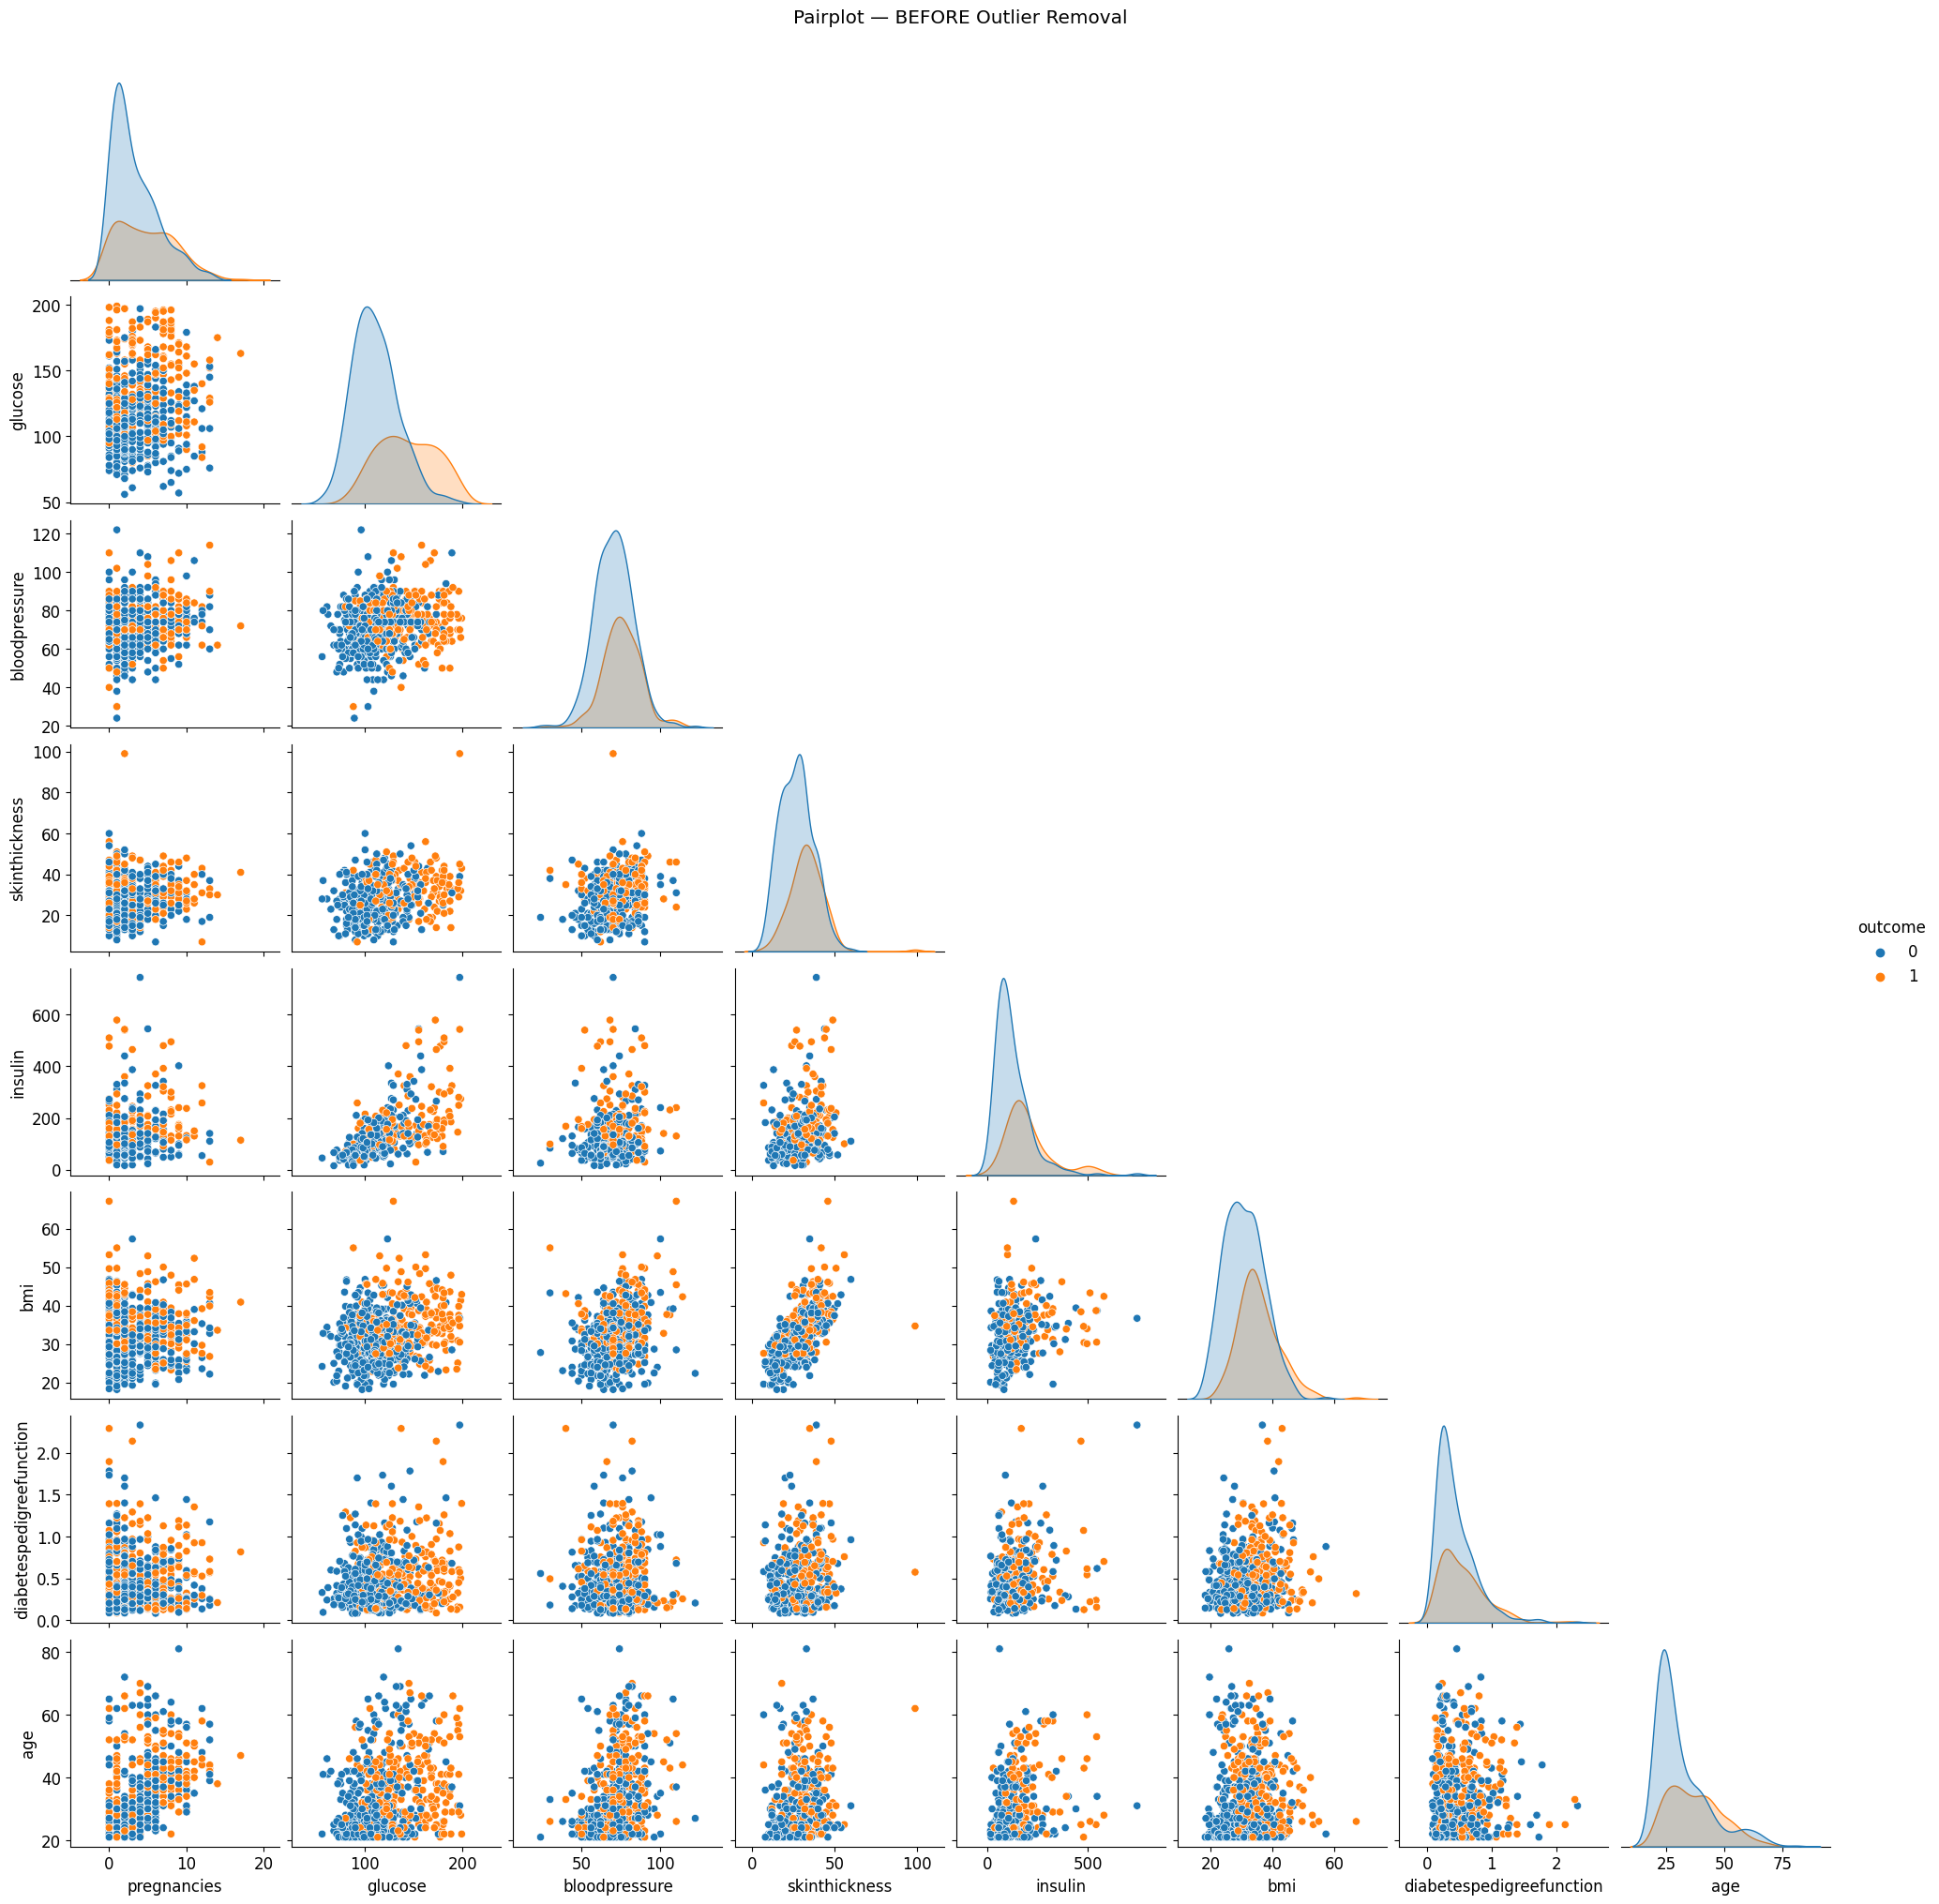

In [52]:
sns.pairplot(df_train, corner=True, hue='outcome')
plt.suptitle('Pairplot — BEFORE Outlier Removal', y=1.02)
plt.show()

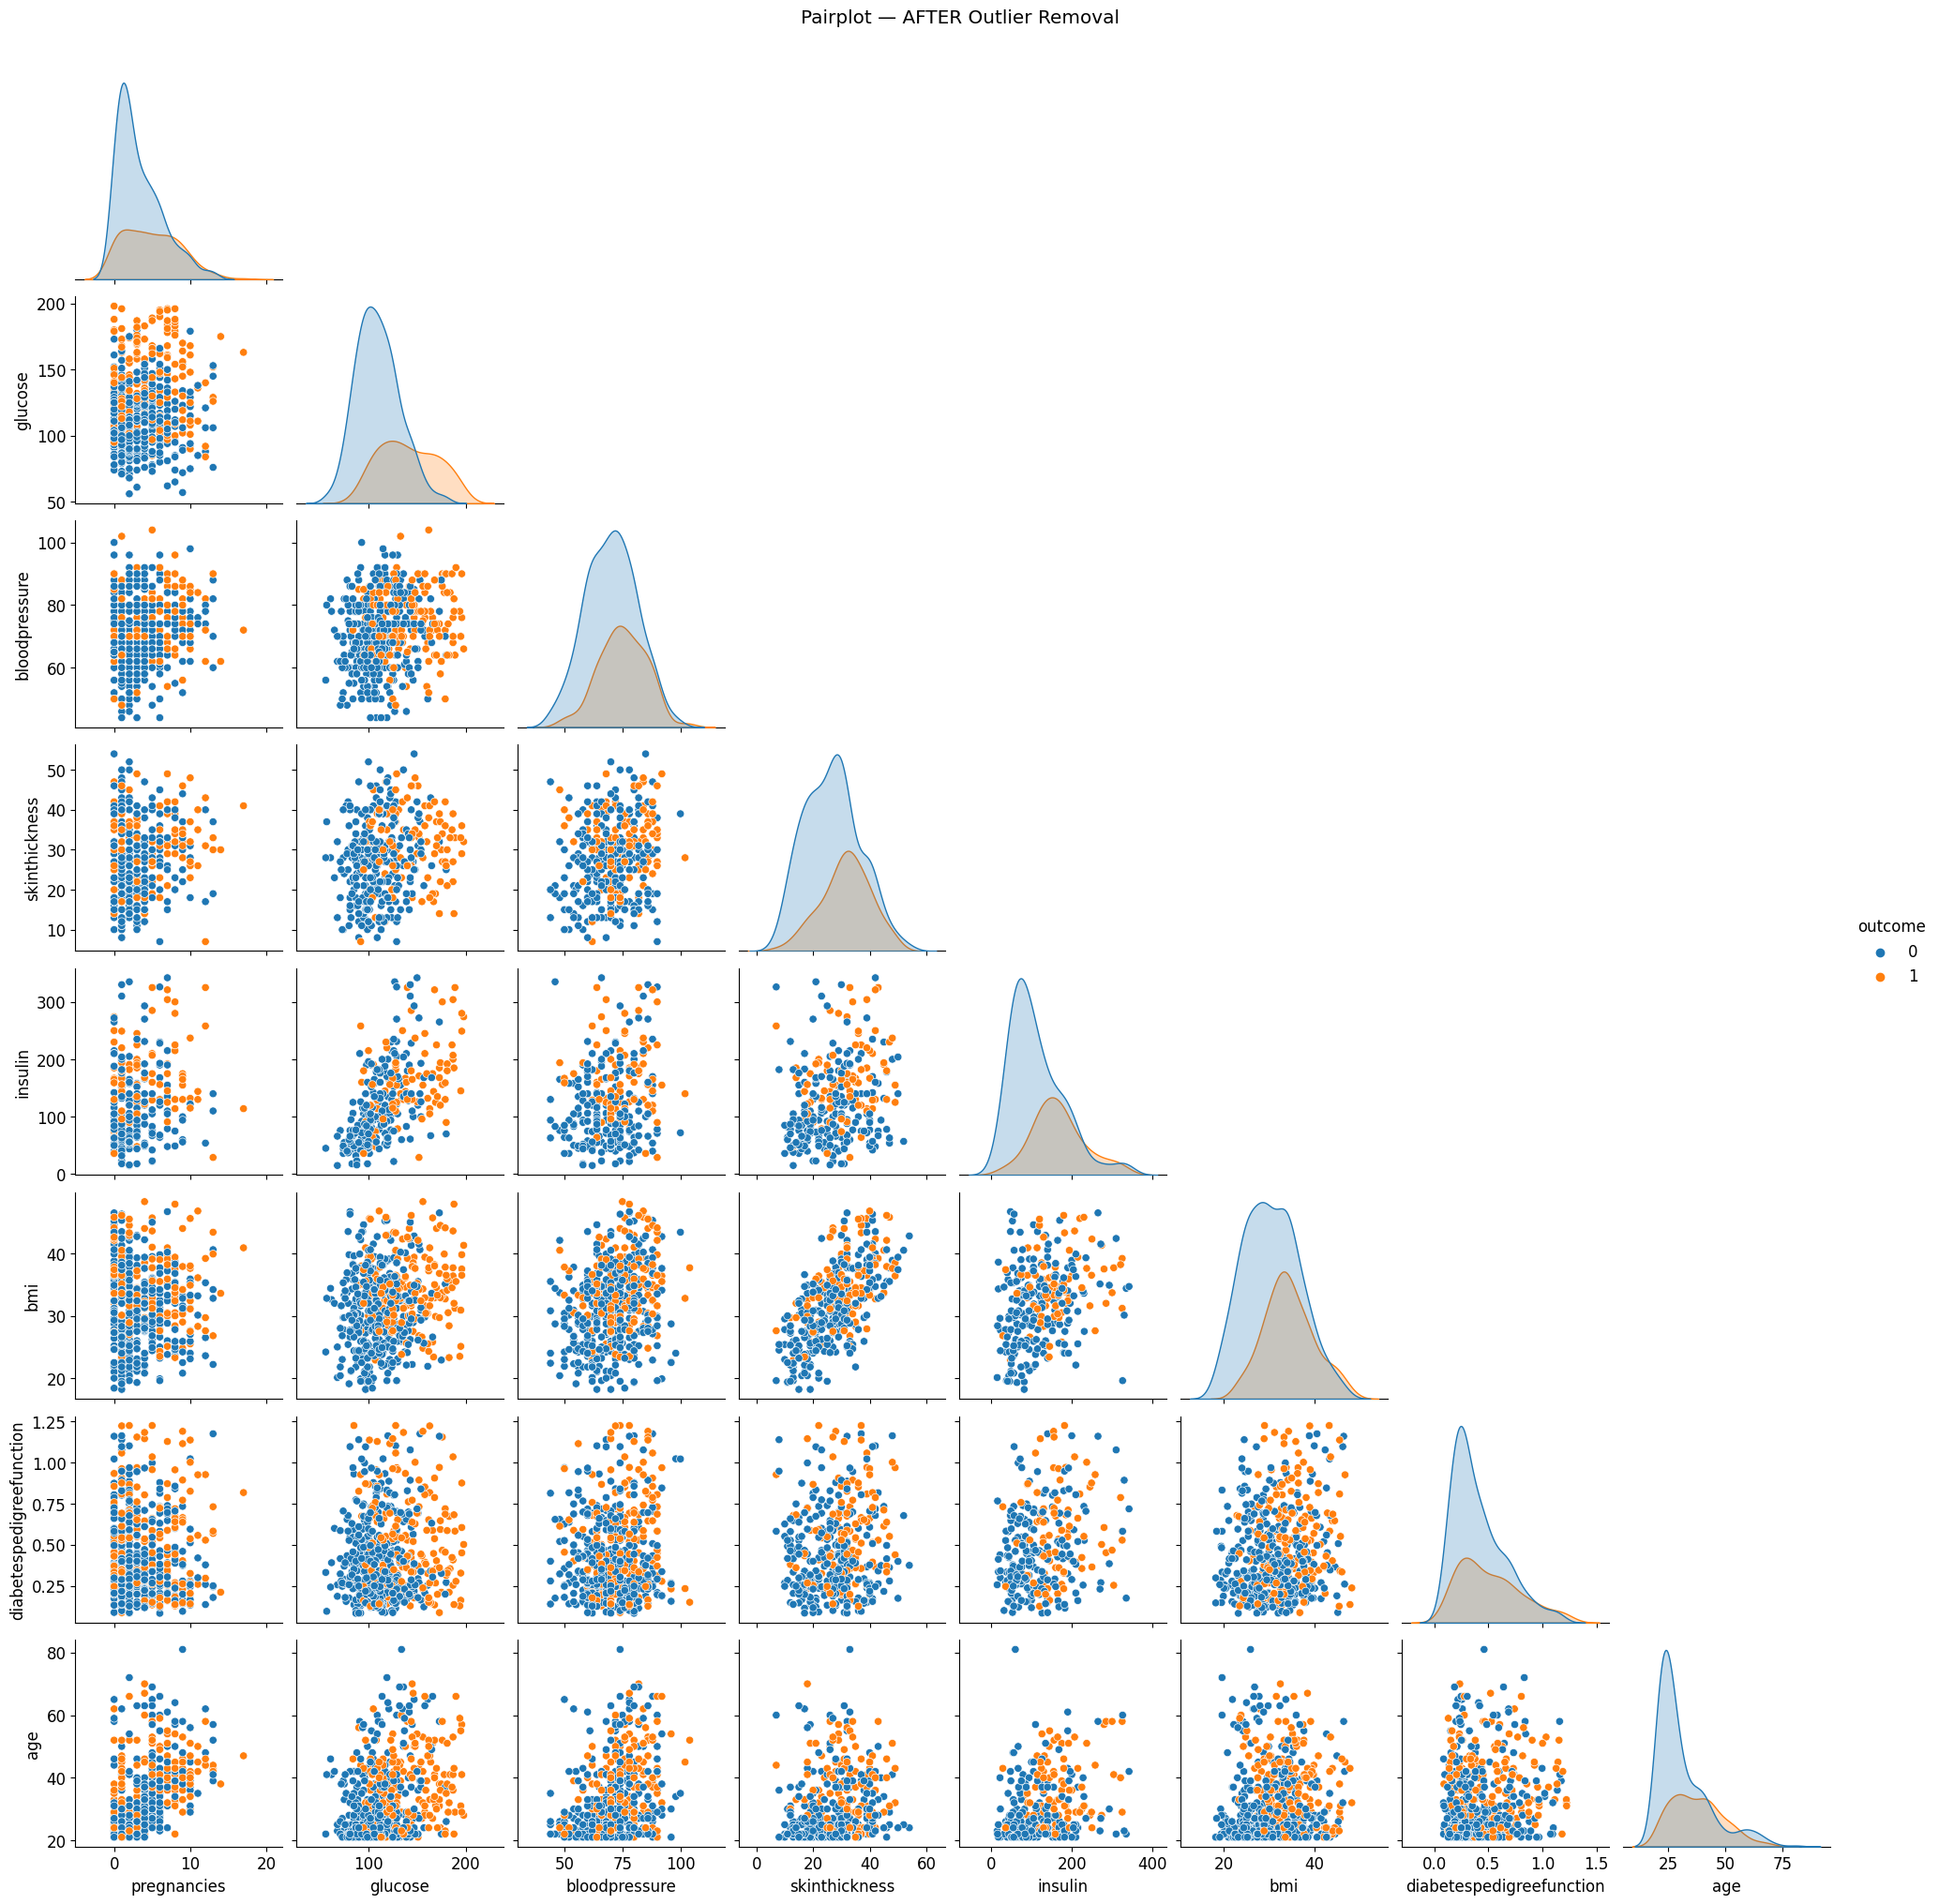

In [53]:
sns.pairplot(df_cleaned, corner=True, hue='outcome')
plt.suptitle('Pairplot — AFTER Outlier Removal', y=1.02)
plt.show()

## 7. Exploratory Data Analysis

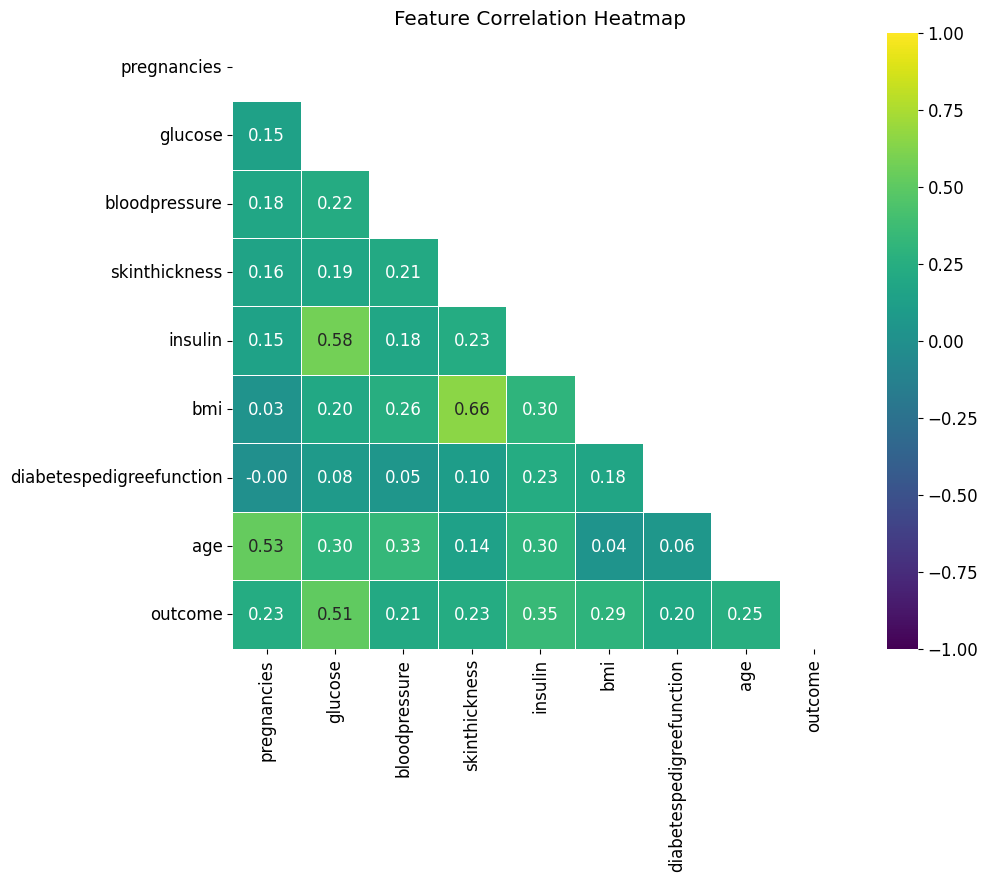

In [54]:
# Full correlation heatmap
corr_df = df_cleaned.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_df, dtype=bool))

plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.size': 12})
sns.heatmap(corr_df, cmap='viridis', vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", square=True, linewidths=.5, mask=mask)
plt.title('Feature Correlation Heatmap')
plt.show()

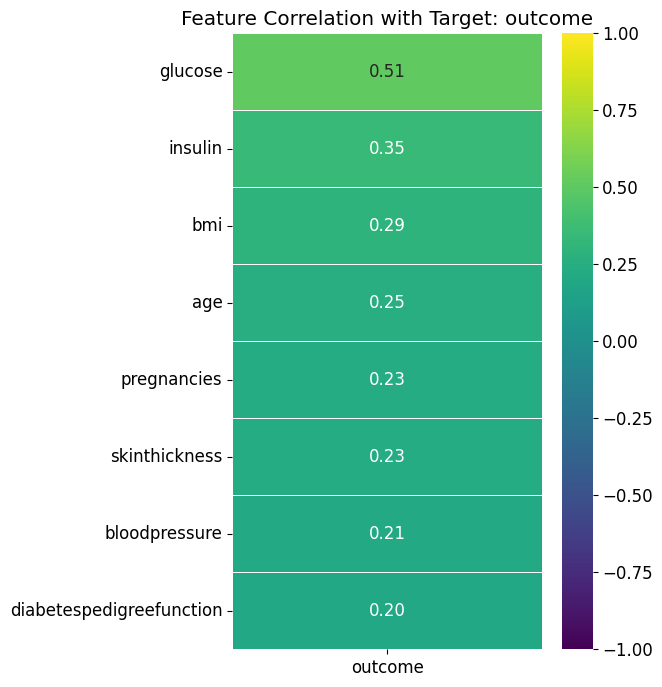

In [55]:
plot_target_correlation(df_cleaned, 'outcome')

## 8. Baseline Model

- **Preprocessor:** Uniform `StandardScaler` for all features.
- **Feature:** Only `glucose` (highest correlation with outcome).
- **Purpose:** Establishes a performance floor before applying feature-specific scaling.

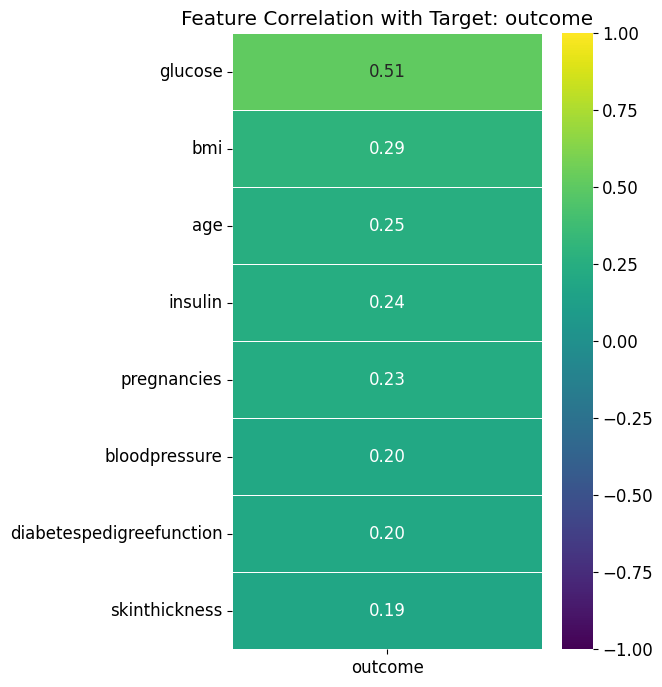

In [56]:
# Baseline preprocessor: StandardScaler for ALL features
preprocessor_combined = ColumnTransformer([
    ('zero',  Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), zero_check_columns),
    ('other', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), other_columns)
], verbose_feature_names_out=False)

preprocessor_combined.fit(X_train_cleaned)
new_df = preprocessor_combined.transform(X_train_cleaned)
new_df = pd.DataFrame(data=new_df,
                      columns=preprocessor_combined.get_feature_names_out(),
                      index=X_train_cleaned.index)
new_df_train = pd.concat([new_df, y_train_cleaned], axis=1)

plot_target_correlation(new_df_train, 'outcome')

In [57]:
# Baseline model: single feature (glucose) + uniform StandardScaler
# Purpose: establishes a performance floor before applying tailored preprocessing
baseline = LogisticRegression(random_state=RSEED)
baseline.fit(new_df_train[['glucose']], y_train_cleaned)
y_baseline_pred = baseline.predict(new_df_train[['glucose']])

print('=== BASELINE MODEL (Glucose only, StandardScaler) ===')
print(f"Accuracy:  {accuracy_score(y_train_cleaned, y_baseline_pred):.2f}")
print(f"Recall:    {recall_score(y_train_cleaned, y_baseline_pred):.2f}")
print(f"Precision: {precision_score(y_train_cleaned, y_baseline_pred):.2f}")
print(classification_report(y_train_cleaned, y_baseline_pred))

=== BASELINE MODEL (Glucose only, StandardScaler) ===
Accuracy:  0.76
Recall:    0.48
Precision: 0.69
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       377
           1       0.69      0.48      0.56       181

    accuracy                           0.76       558
   macro avg       0.74      0.69      0.70       558
weighted avg       0.75      0.76      0.75       558



## 9. Skewness Analysis

Visualizing distributions to decide which scaler is most appropriate per feature group:

| Feature Group | Features | Chosen Scaler |
|:---|:---|:---|
| Symmetric | glucose, bloodpressure, bmi, skinthickness | `StandardScaler` |
| Skewed | insulin, diabetespedigreefunction | `PowerTransformer` (yeo-johnson) |
| Count-based | pregnancies, age | `RobustScaler` |

=== Feature Distributions BEFORE Transformation ===


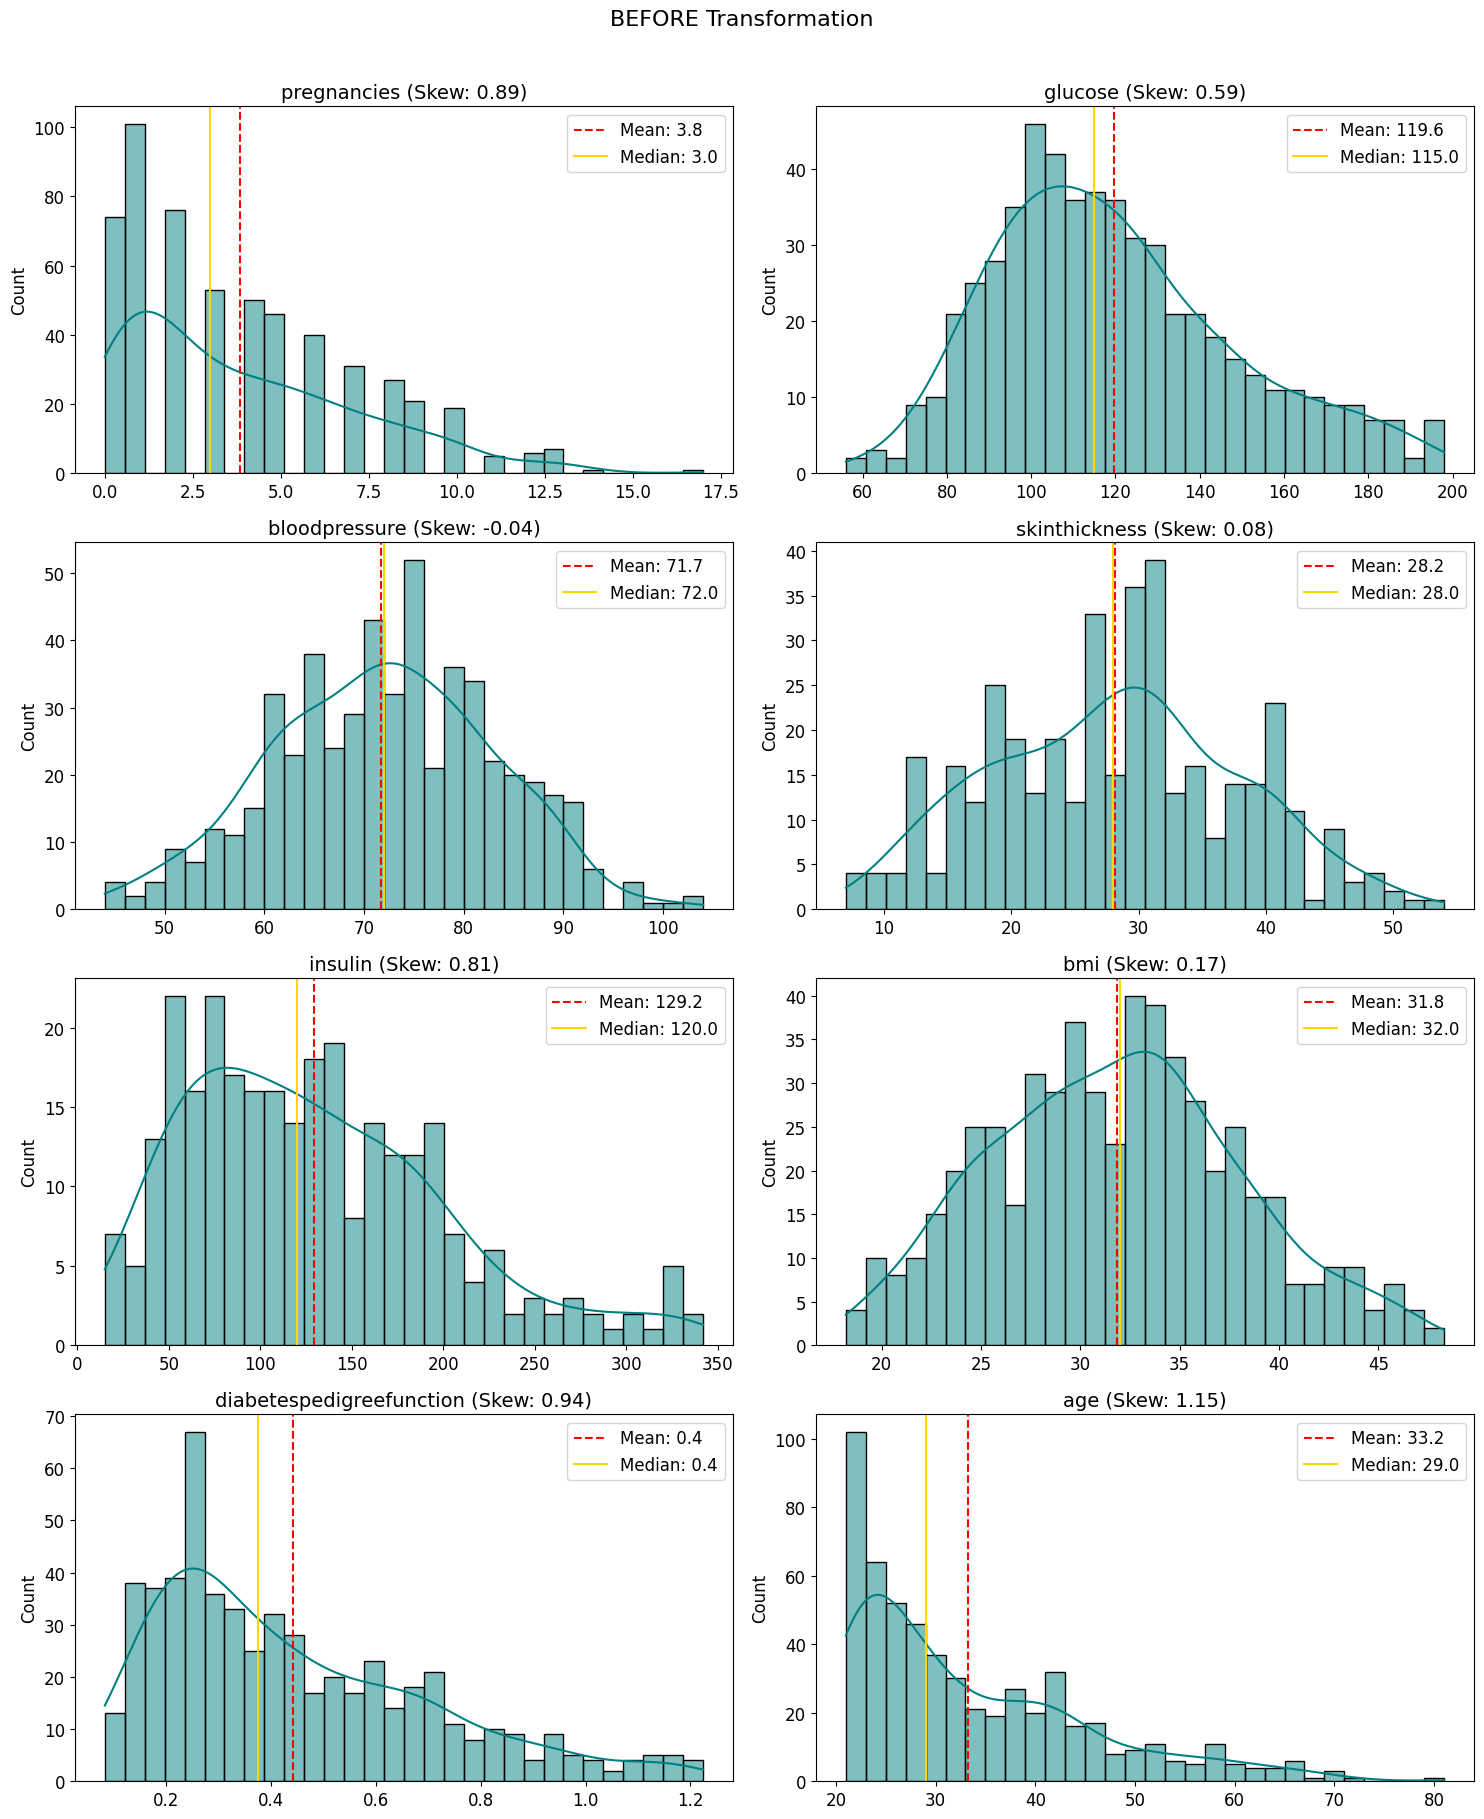

In [58]:
all_features = ['pregnancies', 'glucose', 'bloodpressure', 'skinthickness',
                'insulin', 'bmi', 'diabetespedigreefunction', 'age']

# Before transformation — checking raw distributions to decide which scaler to use
print("=== Feature Distributions BEFORE Transformation ===")
hist_plot(df_cleaned, all_features, title="BEFORE Transformation")

## 10. Feature-Specific Preprocessing Pipeline

In [59]:
sym_features    = ['glucose', 'bloodpressure', 'bmi', 'skinthickness']
skewed_features = ['insulin', 'diabetespedigreefunction']
count_features  = ['pregnancies', 'age']

# Branch 1: StandardScaler for symmetric/normal-ish features
sym_pipeline = Pipeline([
    ('sym_imputer', SimpleImputer(strategy='median')),
    ('sym_scaler',  StandardScaler())
])

# Branch 2: PowerTransformer for skewed features (normalizes long tails)
skewed_pipeline = Pipeline([
    ('skewed_imputer', SimpleImputer(strategy='median')),
    ('skewed_scaler',  PowerTransformer(method='yeo-johnson'))
])

# Branch 3: RobustScaler for count/age features (handles remaining outliers)
count_pipeline = Pipeline([
    ('count_imputer', SimpleImputer(strategy='median')),
    ('count_scaler',  RobustScaler())
])

preprocessor_separated = ColumnTransformer([
    ('sym',    sym_pipeline,    sym_features),
    ('skewed', skewed_pipeline, skewed_features),
    ('count',  count_pipeline,  count_features)
], verbose_feature_names_out=False)

=== Feature Distributions AFTER Transformation ===


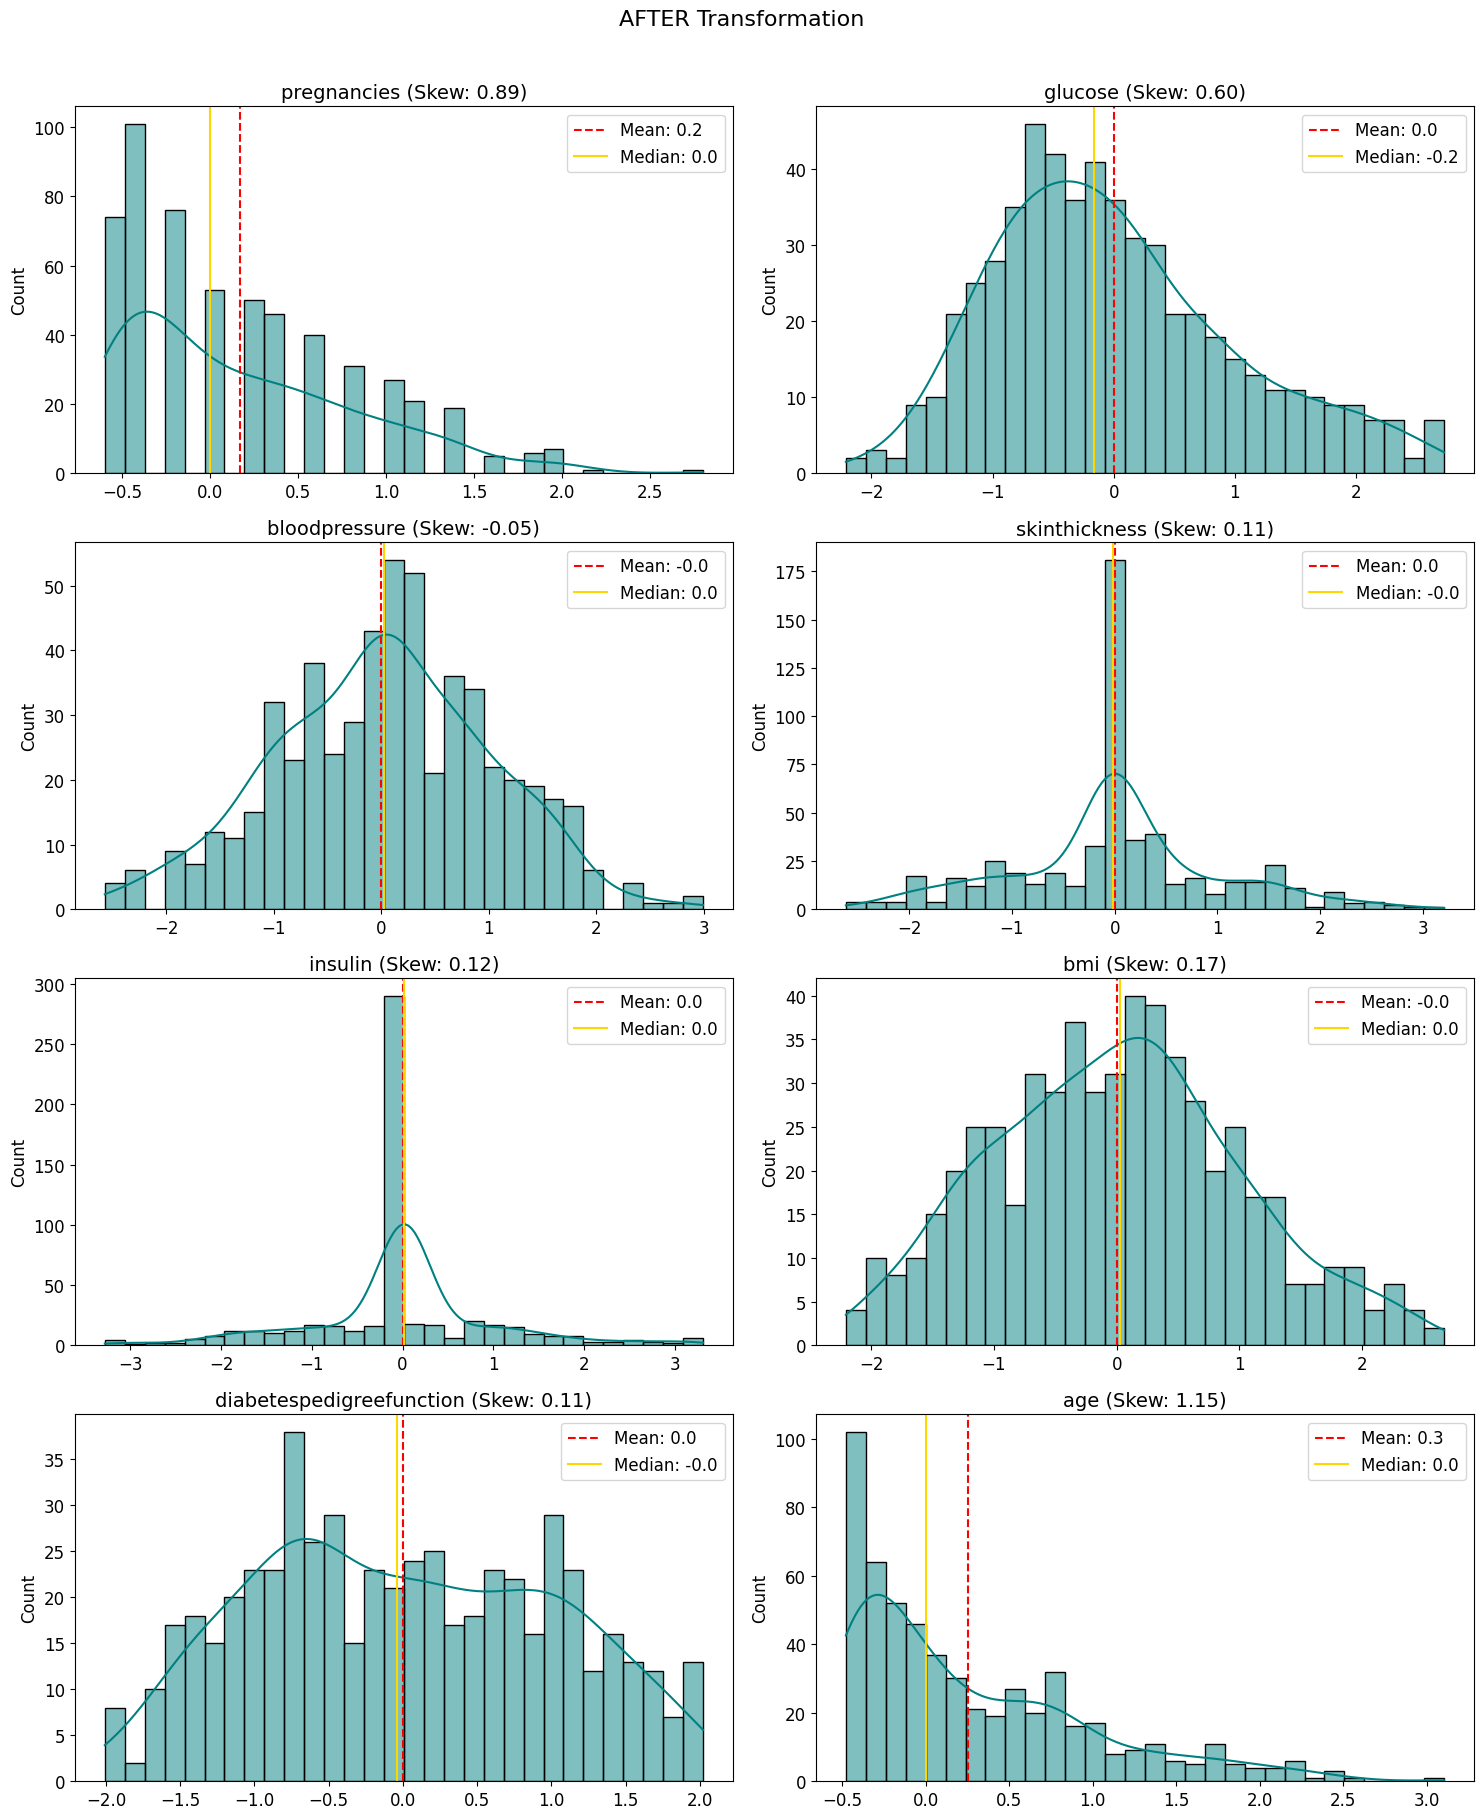

In [60]:
# Fit and transform to verify distributions improved
preprocessor_separated.fit(X_train_cleaned)
X_train_transformed = preprocessor_separated.transform(X_train_cleaned)
transformed_df = pd.DataFrame(X_train_transformed,
                               columns=preprocessor_separated.get_feature_names_out(),
                               index=X_train_cleaned.index)

# After transformation — verifying that skewness has been reduced
print("=== Feature Distributions AFTER Transformation ===")
hist_plot(transformed_df, all_features, title="AFTER Transformation")

## 11. Before vs After Transformation Comparison

Comparing **uniform StandardScaler** vs **feature-specific scaling** across all three classifiers.  
This numerically justifies using `preprocessor_separated` for final hyperparameter tuning.

> ⚠️ Preprocessors are **redefined fresh** here to ensure a clean (unfitted) state inside each pipeline.  
> ⚠️ `DecisionTreeClassifier` uses `max_depth=5` to prevent overfitting on train data, which would make the comparison misleading.

In [61]:
# Fresh preprocessor definitions — ensures clean unfitted state inside each pipeline
preprocessor_combined_fresh = ColumnTransformer([
    ('zero',  Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), zero_check_columns),
    ('other', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), other_columns)
], verbose_feature_names_out=False)

preprocessor_separated_fresh = ColumnTransformer([
    ('sym',    Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]),                      sym_features),
    ('skewed', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', PowerTransformer(method='yeo-johnson'))]), skewed_features),
    ('count',  Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', RobustScaler())]),                        count_features)
], verbose_feature_names_out=False)

# Note: DecisionTree uses max_depth=5 to prevent overfitting in this comparison
lr_before  = Pipeline([('pre', preprocessor_combined_fresh),  ('clf', LogisticRegression(random_state=RSEED, solver='liblinear'))])
dt_before  = Pipeline([('pre', preprocessor_combined_fresh),  ('clf', DecisionTreeClassifier(random_state=RSEED, max_depth=5))])
knn_before = Pipeline([('pre', preprocessor_combined_fresh),  ('clf', KNeighborsClassifier())])

lr_after   = Pipeline([('pre', preprocessor_separated_fresh), ('clf', LogisticRegression(random_state=RSEED, solver='liblinear'))])
dt_after   = Pipeline([('pre', preprocessor_separated_fresh), ('clf', DecisionTreeClassifier(random_state=RSEED, max_depth=5))])
knn_after  = Pipeline([('pre', preprocessor_separated_fresh), ('clf', KNeighborsClassifier())])

comparison_pipelines = {
    'Logistic Regression': (lr_before, lr_after),
    'Decision Tree':       (dt_before, dt_after),
    'KNN':                 (knn_before, knn_after)
}

In [62]:
comparison_results = []

for name, (model_before, model_after) in comparison_pipelines.items():
    model_before.fit(X_train_cleaned, y_train_cleaned)
    model_after.fit(X_train_cleaned, y_train_cleaned)

    y_pred_before = model_before.predict(X_train_cleaned)
    y_pred_after  = model_after.predict(X_train_cleaned)
    y_pred_test   = model_after.predict(X_test)

    comparison_results.append({'Model': name, 'Set': 'Train (Before Transformation)',
                    'Recall':   recall_score(y_train_cleaned, y_pred_before).round(2),
                    'Accuracy': accuracy_score(y_train_cleaned, y_pred_before).round(2)})
    comparison_results.append({'Model': name, 'Set': 'Train (After Transformation)',
                    'Recall':   recall_score(y_train_cleaned, y_pred_after).round(2),
                    'Accuracy': accuracy_score(y_train_cleaned, y_pred_after).round(2)})
    comparison_results.append({'Model': name, 'Set': 'Test',
                    'Recall':   recall_score(y_test, y_pred_test).round(2),
                    'Accuracy': accuracy_score(y_test, y_pred_test).round(2)})

comparison_results_df = pd.DataFrame(comparison_results)
print(comparison_results_df)

                 Model                            Set  Recall  Accuracy
0  Logistic Regression  Train (Before Transformation)    0.58      0.80
1  Logistic Regression   Train (After Transformation)    0.56      0.79
2  Logistic Regression                           Test    0.52      0.70
3        Decision Tree  Train (Before Transformation)    0.63      0.84
4        Decision Tree   Train (After Transformation)    0.63      0.84
5        Decision Tree                           Test    0.54      0.77
6                  KNN  Train (Before Transformation)    0.69      0.83
7                  KNN   Train (After Transformation)    0.70      0.84
8                  KNN                           Test    0.54      0.73


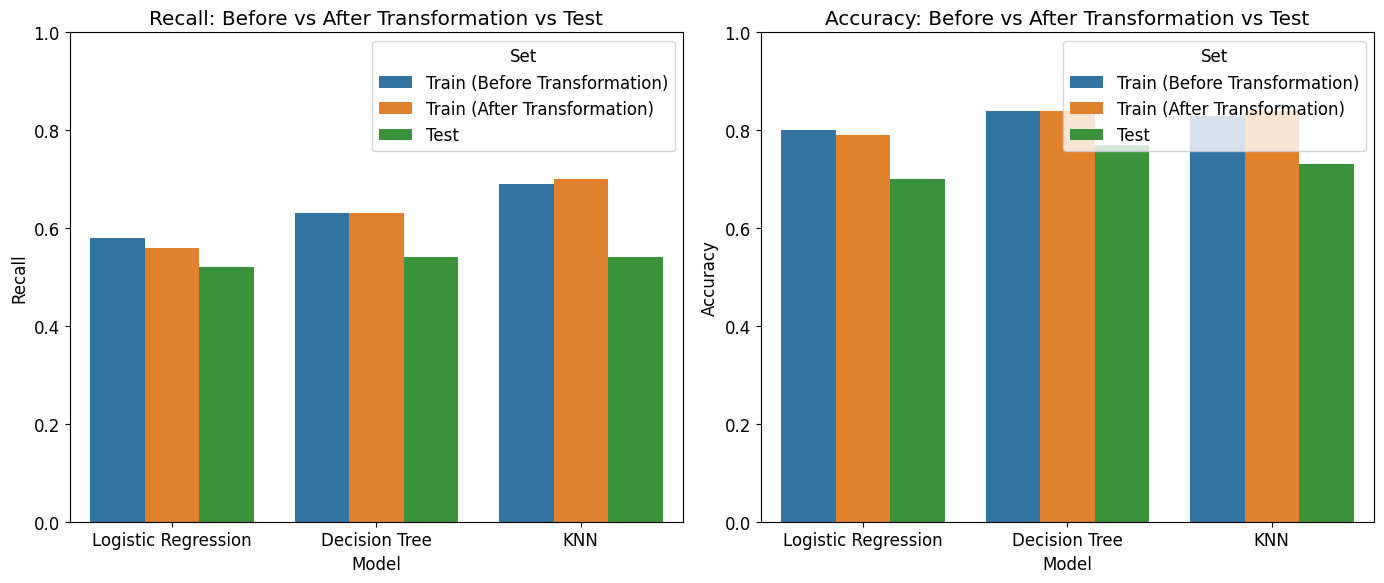

In [63]:
plot_model_comparison(comparison_results_df,
                      title_suffix="Before vs After Transformation vs Test")

## 12. Cross-Validation Check — All 3 Models (No Tuning)

Sanity check for all 3 models using `preprocessor_separated` before hyperparameter tuning.  
Shows Train vs Test performance as a pre-tuning baseline.

**Why Recall as evaluation metric?**  
In medical diagnosis, a **false negative** (missing a diabetic patient) is far more dangerous than a false positive.  
Recall = TP / (TP + FN) — directly measures how well we catch actual diabetic patients.

In [64]:
# Fresh preprocessor for CV — avoids using already-fitted state from Step 10
preprocessor_separated_cv = ColumnTransformer([
    ('sym',    Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]),                      sym_features),
    ('skewed', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', PowerTransformer(method='yeo-johnson'))]), skewed_features),
    ('count',  Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', RobustScaler())]),                        count_features)
], verbose_feature_names_out=False)

# Note: DecisionTree uses max_depth=5 to prevent misleading train recall of 1.0
cv_models = {
    'Logistic Regression': LogisticRegression(random_state=RSEED),
    'Decision Tree':       DecisionTreeClassifier(random_state=RSEED, max_depth=5),
    'KNN':                 KNeighborsClassifier()
}

cv_results = []

for name, clf in cv_models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor_separated_cv),
        ('clf', clf)
    ])

    cv_scores      = cross_val_score(pipeline, X_train_cleaned, y_train_cleaned, cv=5, scoring='recall')
    y_cv_predicted = cross_val_predict(pipeline, X_train_cleaned, y_train_cleaned, cv=5)

    # Fit on full train to also get test predictions for the comparison plot
    pipeline.fit(X_train_cleaned, y_train_cleaned)
    y_test_predicted = pipeline.predict(X_test)

    cv_results.append({'Model': name, 'Set': 'Train (No Tuning)',
                       'Recall':   recall_score(y_train_cleaned, y_cv_predicted).round(2),
                       'Accuracy': accuracy_score(y_train_cleaned, y_cv_predicted).round(2)})
    cv_results.append({'Model': name, 'Set': 'Test (No Tuning)',
                       'Recall':   recall_score(y_test, y_test_predicted).round(2),
                       'Accuracy': accuracy_score(y_test, y_test_predicted).round(2)})

    print(f'=== {name} — Cross Validation (No Tuning) ===')
    print(f'Mean CV Recall: {cv_scores.mean():.2f}  ±  {cv_scores.std():.2f}')
    print(f"Accuracy:  {accuracy_score(y_train_cleaned, y_cv_predicted):.2f}")
    print(f"Recall:    {recall_score(y_train_cleaned, y_cv_predicted):.2f}")
    print(f"Precision: {precision_score(y_train_cleaned, y_cv_predicted):.2f}")
    print(classification_report(y_train_cleaned, y_cv_predicted))
    print("-" * 40)

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

=== Logistic Regression — Cross Validation (No Tuning) ===
Mean CV Recall: 0.54  ±  0.08
Accuracy:  0.78
Recall:    0.54
Precision: 0.71
              precision    recall  f1-score   support

           0       0.80      0.89      0.85       377
           1       0.71      0.54      0.61       181

    accuracy                           0.78       558
   macro avg       0.76      0.72      0.73       558
weighted avg       0.77      0.78      0.77       558

----------------------------------------
=== Decision Tree — Cross Validation (No Tuning) ===
Mean CV Recall: 0.55  ±  0.11
Accuracy:  0.75
Recall:    0.55
Precision: 0.63
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       377
           1       0.63      0.55      0.59       181

    accuracy                           0.75       558
   macro avg       0.72      0.70      0.71       558
weighted avg       0.74      0.75      0.75       558

-------------------------------------

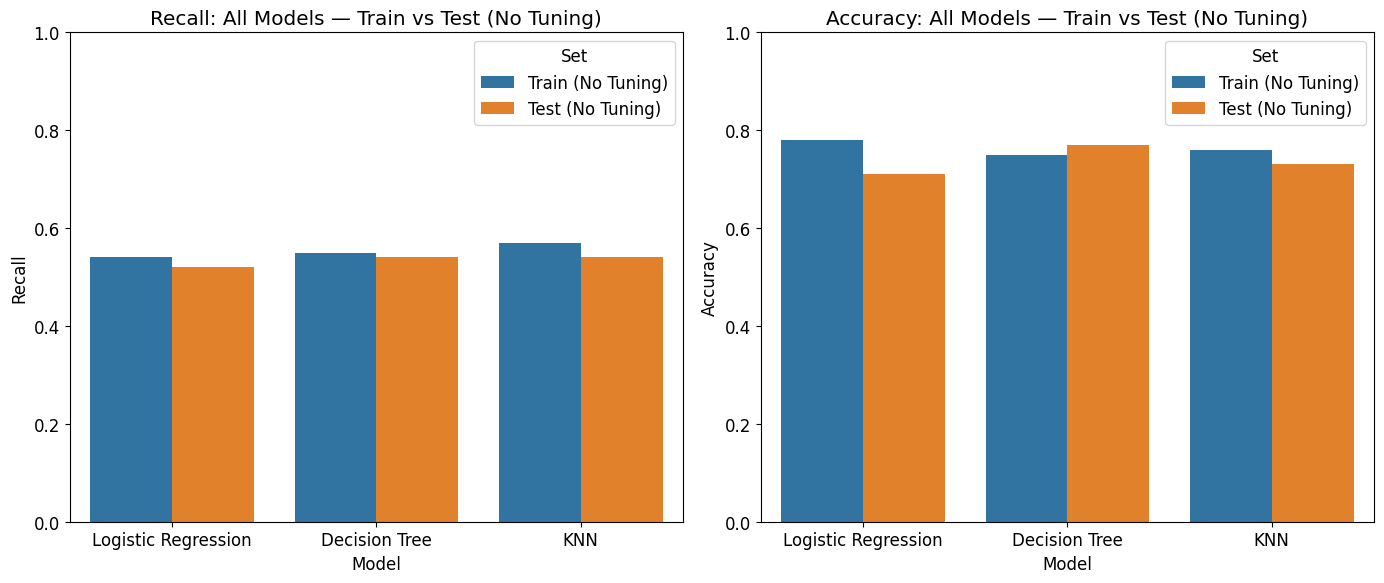

In [65]:
plot_model_comparison(cv_results_df,
                      title_suffix="All Models — Train vs Test (No Tuning)")

## 13. Hyperparameter Tuning with GridSearchCV

All models use `preprocessor_separated` (feature-specific scaling).  
Scoring metric: **recall** — to minimize false negatives.  

> sklearn clones the estimator on each fold internally, so reusing `preprocessor_separated` here is safe.

In [66]:
# --- Logistic Regression ---
lr_model  = Pipeline([('pre', preprocessor_separated), ('clf', LogisticRegression(random_state=RSEED, solver='liblinear'))])
lr_params = {
    'clf__C':            [0.01, 0.1, 1, 10],
    'clf__penalty':      ['l1', 'l2'],
    'clf__class_weight': [None, 'balanced']
}
lr_grid = GridSearchCV(lr_model, lr_params, cv=5, scoring='recall', n_jobs=-1).fit(X_train_cleaned, y_train_cleaned)

# --- Decision Tree ---
dt_model  = Pipeline([('pre', preprocessor_separated), ('clf', DecisionTreeClassifier(random_state=RSEED))])
dt_params = {
    'clf__max_depth':         [3, 5, 7],
    'clf__min_samples_split': [5, 10],
    'clf__criterion':         ['gini', 'entropy']
}
dt_grid = GridSearchCV(dt_model, dt_params, cv=5, scoring='recall', n_jobs=-1).fit(X_train_cleaned, y_train_cleaned)

# --- KNN ---
knn_model  = Pipeline([('pre', preprocessor_separated), ('clf', KNeighborsClassifier())])
knn_params = {
    'clf__n_neighbors': [5, 7, 9, 11],
    'clf__weights':     ['uniform', 'distance']
}
knn_grid = GridSearchCV(knn_model, knn_params, cv=5, scoring='recall', n_jobs=-1).fit(X_train_cleaned, y_train_cleaned)

In [67]:
# Best hyperparameters found by GridSearchCV
print("=== BEST HYPERPARAMETERS ===")
print(f"Logistic Regression: {lr_grid.best_params_}")
print(f"  → Best CV Recall:  {lr_grid.best_score_:.2f}")
print(f"Decision Tree:       {dt_grid.best_params_}")
print(f"  → Best CV Recall:  {dt_grid.best_score_:.2f}")
print(f"KNN:                 {knn_grid.best_params_}")
print(f"  → Best CV Recall:  {knn_grid.best_score_:.2f}")

=== BEST HYPERPARAMETERS ===
Logistic Regression: {'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
  → Best CV Recall:  0.77
Decision Tree:       {'clf__criterion': 'gini', 'clf__max_depth': 7, 'clf__min_samples_split': 10}
  → Best CV Recall:  0.61
KNN:                 {'clf__n_neighbors': 5, 'clf__weights': 'uniform'}
  → Best CV Recall:  0.57


## 14. Final Test Set Evaluation

> **Note:** `X_test` is passed **raw** (unscaled, with original NaNs intact).  
> Preprocessing (imputation + scaling) is handled **internally** by each pipeline.  
> This mirrors real-world usage where unseen data arrives unprocessed.

In [68]:
best_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Decision Tree":       dt_grid.best_estimator_,
    "KNN":                 knn_grid.best_estimator_
}

print("=== FINAL TEST SET EVALUATION (Unseen Data) ===")
for name, model in best_models.items():
    y_test_predicted = model.predict(X_test)
    print(f"\nModel: {name}")
    print(f"Test Recall:   {recall_score(y_test, y_test_predicted):.2f}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_test_predicted):.2f}")
    print(f'Detailed Report:\n{classification_report(y_test, y_test_predicted)}')
    print("-" * 30)

=== FINAL TEST SET EVALUATION (Unseen Data) ===

Model: Logistic Regression
Test Recall:   0.80
Test Accuracy: 0.69
Detailed Report:
              precision    recall  f1-score   support

           0       0.85      0.64      0.73       100
           1       0.54      0.80      0.65        54

    accuracy                           0.69       154
   macro avg       0.70      0.72      0.69       154
weighted avg       0.74      0.69      0.70       154

------------------------------

Model: Decision Tree
Test Recall:   0.43
Test Accuracy: 0.69
Detailed Report:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       100
           1       0.59      0.43      0.49        54

    accuracy                           0.69       154
   macro avg       0.66      0.63      0.64       154
weighted avg       0.68      0.69      0.68       154

------------------------------

Model: KNN
Test Recall:   0.54
Test Accuracy: 0.73
Detailed Report:
   

In [ ]:
# Train vs Test comparison after GridSearchCV tuning
final_results = []

for name, model in best_models.items():
    y_train_pred = model.predict(X_train_cleaned)
    y_test_pred  = model.predict(X_test)

    final_results.append({'Model': name, 'Set': 'Train',
                          'Recall':   recall_score(y_train_cleaned, y_train_pred).round(2),
                          'Accuracy': accuracy_score(y_train_cleaned, y_train_pred).round(2)})
    final_results.append({'Model': name, 'Set': 'Test',
                          'Recall':   recall_score(y_test, y_test_pred).round(2),
                          'Accuracy': accuracy_score(y_test, y_test_pred).round(2)})

final_results_df = pd.DataFrame(final_results)

print(final_results_df)

                 Model    Set  Recall  Accuracy
0  Logistic Regression  Train    0.77      0.73
1  Logistic Regression   Test    0.80      0.69
2        Decision Tree  Train    0.68      0.87
3        Decision Tree   Test    0.43      0.69
4                  KNN  Train    0.70      0.84
5                  KNN   Test    0.54      0.73


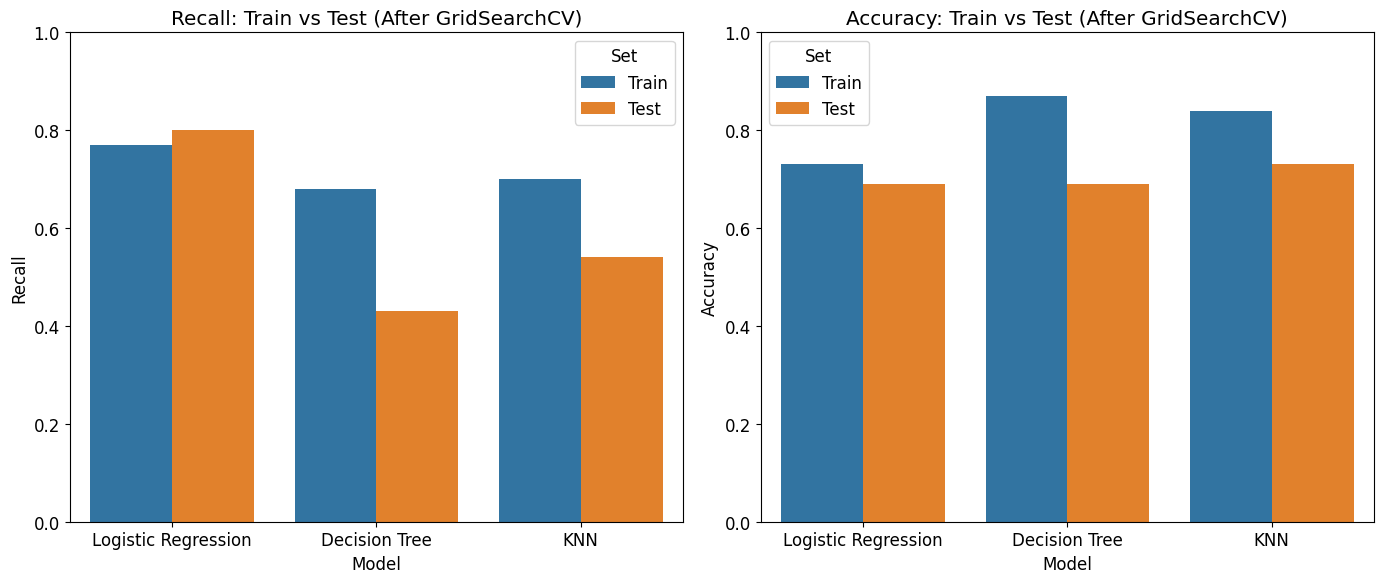

<Figure size 640x480 with 0 Axes>

In [75]:
plot_model_comparison(final_results_df,
                      title_suffix="Train vs Test (After GridSearchCV)")
plt.savefig('images/Recall & Accuracy: Train vs Test (After GridSearchCV).png')

## 15. Confusion Matrices — All Models

Shows the breakdown per model of:
- **True Positives** — diabetic patients correctly identified
- **False Negatives** — diabetic patients missed (most critical to minimize)
- **True Negatives** — healthy patients correctly identified
- **False Positives** — healthy patients incorrectly flagged

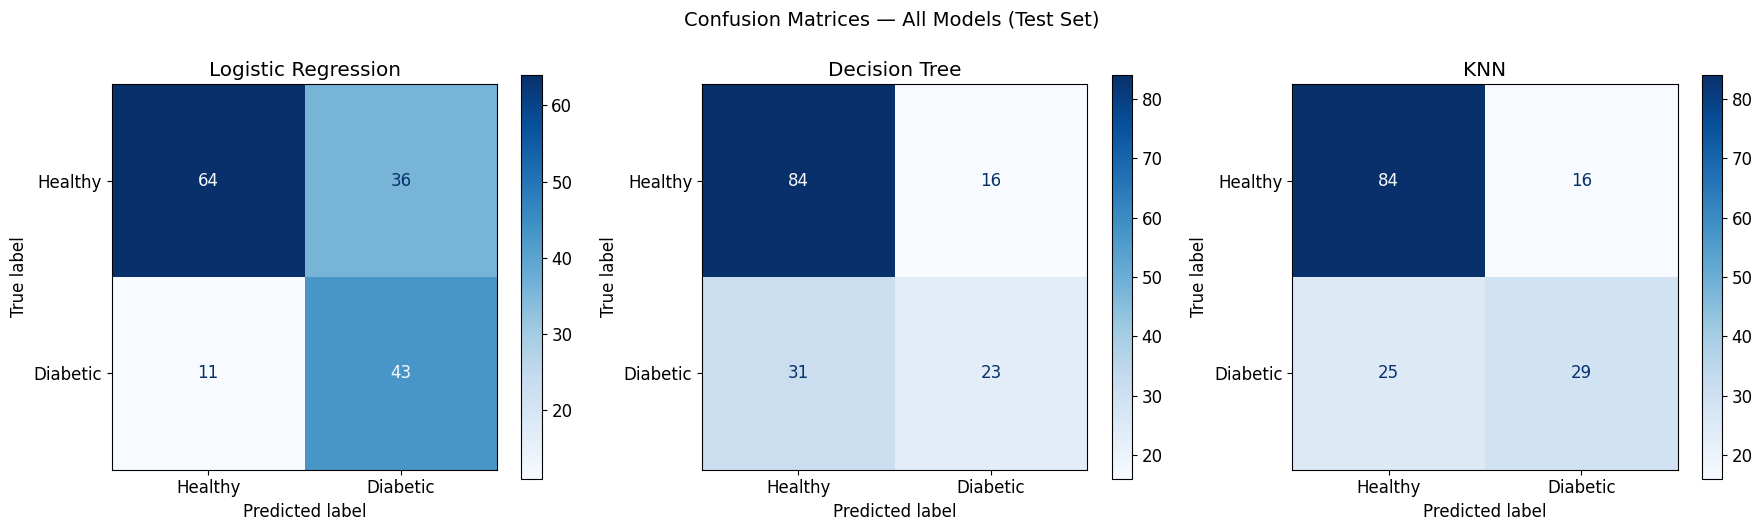

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, best_models.items()):
    y_test_pred_cm = model.predict(X_test)
    cm = confusion_matrix(y_test, y_test_pred_cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Diabetic'])
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('images/confusion_matrices_all.png')
plt.show()

## 16. ROC Curve — All Models

Shows the tradeoff between **True Positive Rate (Recall)** and **False Positive Rate** at different thresholds.  
A higher AUC means the model is better at distinguishing diabetic from healthy patients.

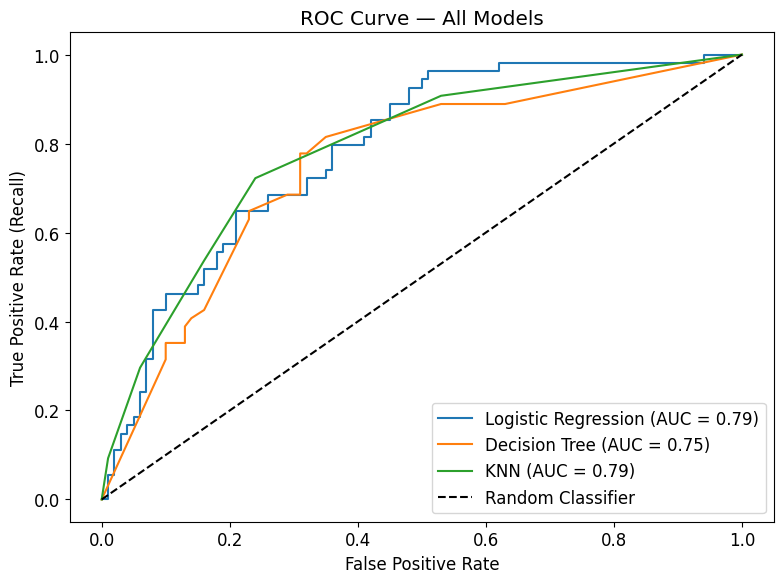

In [72]:
plt.figure(figsize=(8, 6))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('images/roc_curve.png')
plt.show()

## 17. Precision-Recall Curve — All Models

More informative than the ROC curve for **imbalanced datasets** like this one (~35% diabetic).  
Shows the tradeoff between catching all diabetic patients (recall) and avoiding false alarms (precision).

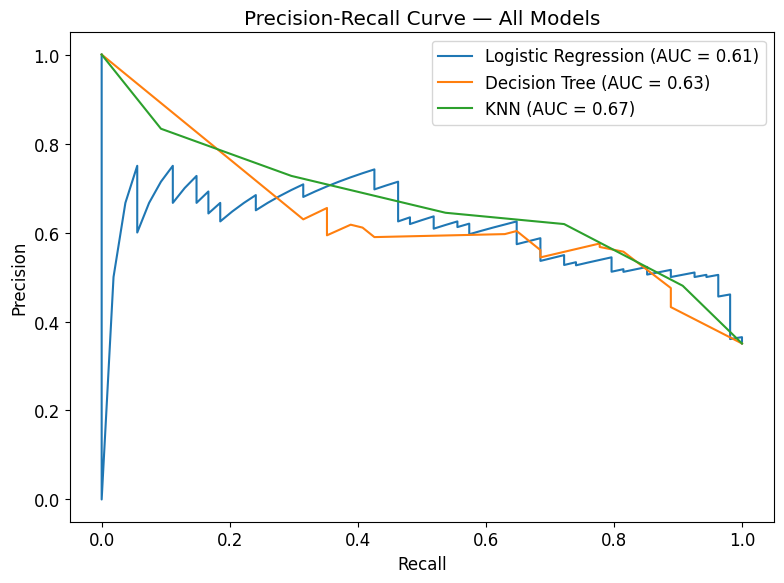

In [73]:
plt.figure(figsize=(8, 6))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('images/precision_recall_curve.png')
plt.show()

## 18. Feature Importance — Decision Tree

Shows which features the best Decision Tree model relies on most for its predictions.  
Useful for explainability — helps understand what drives the diabetes prediction.

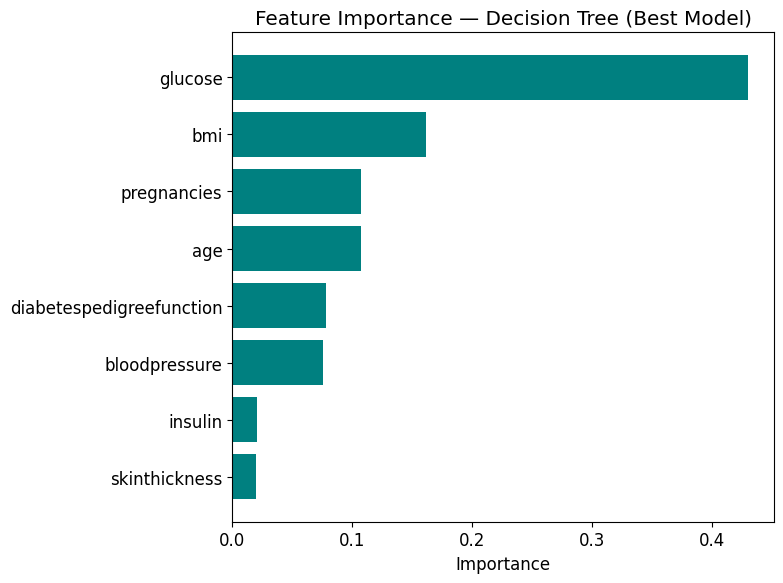

In [74]:
best_dt = best_models["Decision Tree"]

# Extract feature names and importances directly from the best pipeline
feature_names = best_dt.named_steps['pre'].get_feature_names_out()
importances   = best_dt.named_steps['clf'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Feature Importance — Decision Tree (Best Model)')
plt.tight_layout()
plt.savefig('images/feature_importance.png')
plt.show()